In [1]:
import os
os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")
import sys
import numpy as np
import pandas as pd

In [2]:
import scanpy as sc
import palantir

In [3]:
import matplotlib.pyplot as plt

# cell rank

In [4]:
ery_mk_ad = sc.read_h5ad('data/ery_mk_Aug1.h5ad')

In [8]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

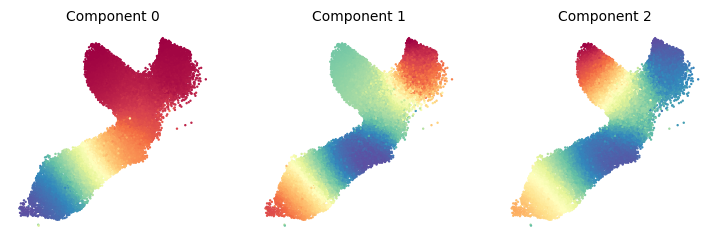

In [ ]:
palantir.plot.plot_diffusion_components(ery_mk_ad, dm_res='DM_EigenVectors_multiscaled')
plt.show()

In [36]:
ery_mk_ad.obsm['DM_EigenVectors_multiscaled'].shape

(22740, 3)

In [38]:
print(ery_mk_ad.obsm['DM_EigenVectors_multiscaled'].std(axis=0))

[2.6396816  0.6617021  0.65143204]


In [35]:
print(ery_mk_ad.obsm['DM_EigenVectors'].std(axis=0))

[1.5935826e-06 6.6313911e-03 6.6313827e-03 6.6313832e-03 6.6313078e-03]


In [10]:
# transition matrix
# import cellrank as cr
import scvelo as scv
import PINN

In [ ]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [69]:
ck = cr.kernels.ConnectivityKernel(ery_mk_ad)
ck.compute_transition_matrix()

pk = cr.kernels.PseudotimeKernel(ery_mk_ad, time_key="palantir_pseudotime")
pk.compute_transition_matrix(threshold_scheme='soft')

  0%|          | 0/22740 [00:00<?, ?cell/s]

PseudotimeKernel[n=22740, dnorm=False, scheme='soft', b=10.0, nu=0.5]

In [ ]:
pk.plot_projection()

combined_kernel = ck *0.8 + pk*0.2
combined_kernel.compute_transition_matrix()
combined_kernel.plot_projection()

In [63]:
from PINN.functions import reader_funs

In [70]:
T_M = pk.transition_matrix
cellstate_key = 'DM_EigenVectors'
delta_DM, neighbors = reader_funs.sample_deltax_from_transition(ery_mk_ad, T_M, xkey=cellstate_key)

cellstate_ad = PINN.tl.make_coord_adata(ery_mk_ad, cellstate_key=cellstate_key, n_dimension=7)
cellstate_ad.layers['velocity'] = delta_DM


# compute velocity graph
vkey = 'velocity'
scv.tl.velocity_graph(cellstate_ad,  vkey='velocity', xkey='cellstate', n_jobs=20)

computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

    finished (0:00:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


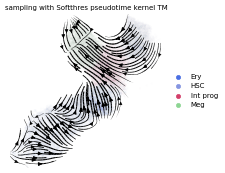

In [72]:
# vis
fig_velocity = plt.figure(dpi=50, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title='sampling with Softthres pseudotime kernel TM ', )
                                # save=f"{result_dir}/{vkey}_velo.png")

In [79]:
knn_dx = []
for i in range(20):
    knn_delta_dm, neighbors = reader_funs.sample_deltax_from_knn(ery_mk_ad, T_M, xkey=cellstate_key, temperature=1, progressbar=False)
    knn_dx.append(knn_delta_dm)

knn_dx = np.stack(knn_dx)

In [76]:
knn_dx.shape

(10, 22740, 5)

In [ ]:
cellstate_key = 'DM_EigenVectors_scaled'

cellstate_ad = PINN.tl.make_coord_adata(ery_mk_ad, cellstate_key=cellstate_key, n_dimension=5)
# compute velocity graph
vkey = 'velocity from KNN sampled idx'


cellstate_ad.layers[vkey] = knn_dx.mean(axis=0)
scv.tl.velocity_graph(cellstate_ad,  vkey=vkey, xkey='cellstate', n_jobs=20)
# vis
fig_velocity = plt.figure(dpi=50, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title=vkey, )
                                # save=f"{result_dir}/{vkey}_velo.png")

computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

5087.72s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5087.90s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.09s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.26s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.45s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.63s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.81s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.98s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5089.16s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5089.34s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5089.52s - pydevd: Sending message related to proc

    finished (0:00:23) --> added 
    'velocity from KNN sampled idx_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:06) --> added
    'velocity from KNN sampled idx_umap', embedded velocity vectors (adata.obsm)


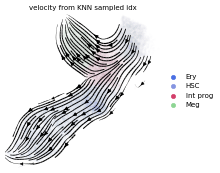

In [ ]:
# compute velocity graph
vkey = 'velocity from KNN sampled idx'

cellstate_key = 'DM_EigenVectors'
cellstate_ad.layers[vkey] = knn_dx.mean(axis=0)
scv.tl.velocity_graph(cellstate_ad,  vkey=vkey, xkey='cellstate', n_jobs=20)
# vis
fig_velocity = plt.figure(dpi=50, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title=vkey, )
                                # save=f"{result_dir}/{vkey}_velo.png")

In [ ]:
ery_mk_ad.obsm['delta_DM'] = knn_dx.mean(axis=0)

## DM eigen vector scaled by std

In [94]:
DM = ery_mk_ad.obsm['DM_EigenVectors'].copy()
ery_mk_ad.obsm['DM_EigenVectors_scaled'] = DM / DM.std(axis=0)

computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

7634.44s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7634.61s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7634.80s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7634.98s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.17s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.35s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.53s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.71s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.89s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7636.29s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7636.48s - pydevd: Sending message related to proc

    finished (0:00:23) --> added 
    'velocity from KNN sampled idx_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:04) --> added
    'velocity from KNN sampled idx_umap', embedded velocity vectors (adata.obsm)


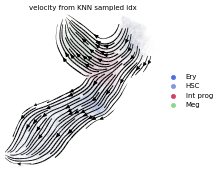

In [95]:
# compute velocity graph
vkey = 'velocity from KNN sampled idx'
cellstate_key = 'DM_EigenVectors_scaled'

# sample
knn_dx_scaled = []
for i in range(20):
    knn_delta_dm, neighbors = reader_funs.sample_deltax_from_knn(ery_mk_ad, T_M, xkey=cellstate_key, temperature=1, progressbar=False)
    knn_dx_scaled.append(knn_delta_dm)

knn_dx_scaled = np.stack(knn_dx_scaled)


# 
cellstate_ad = PINN.tl.make_coord_adata(ery_mk_ad, cellstate_key=cellstate_key, n_dimension=5)
cellstate_ad.layers[vkey] = knn_dx_scaled.mean(axis=0)


# vis
scv.tl.velocity_graph(cellstate_ad,  vkey=vkey, xkey='cellstate', n_jobs=20)
fig_velocity = plt.figure(dpi=50, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title=vkey, )
                                # save=f"{result_dir}/{vkey}_velo.png")

In [221]:
ery_mk_ad.obs['timepoint_tx_days'] = ery_mk_ad.obs['timepoint_tx_days'].astype(int)

In [222]:
ery_mk_ad.write_h5ad('data/ery_mk_Aug1.h5ad')

# check density

In [7]:
ery_mk_ad = sc.read_h5ad('data/ery_mk_Aug1.h5ad')
tompos_ad = sc.read_h5ad('data/tom_pos.h5ad')

In [25]:
cb_inter = np.intersect1d(ery_mk_ad.obs_names, tompos_ad.obs_names)
ery_mk_ad = ery_mk_ad[cb_inter].copy()
ery_mk_ad.obsm['DM_scaled'] = tompos_ad[cb_inter].obsm['DM_scaled'].copy()

In [27]:
from PINN import reader

AttributeError: partially initialized module 'torch._dynamo' has no attribute 'config' (most likely due to a circular import)

In [ ]:
space = 'DM_scaled'
for bw in [0.5,0.6,0.8,1]:
    full_DS = reader.TwoTimpepoint_AnnDS(
                                AnnData=ery_mk_ad, 
                                split = None,
                                n_dimension = None,
                                cellstate_key= space,
                                log_transform=False,
                                norm_time='min_minus',
                                deltax_key='Delta_DM',
                                kde_kws = {'bw_method':bw},
                                batchsize=300)
                            
    fig, axs = PINN.pl.params_in_umap(ery_mk_ad, full_DS.u_b, param=f'{space} {bw} u');
    fig.savefig(f"results/ery_mk/{space}_{bw}_u_b.png")


In [ ]:
for space in ['DM_EigenVectors', 'DM_EigenVectors_scaled', 'DM_EigenVectors_multiscaled']:
    for bw in [0.5,0.6,0.8,1]:
        full_DS = reader.TwoTimpepoint_AnnDS(
                                    AnnData=ery_mk_ad, 
                                    split = None,
                                    n_dimension = None,
                                    cellstate_key= space,
                                    log_transform=False,
                                    norm_time='min_minus',
                                    deltax_key='Delta_DM',
                                    kde_kws = {'bw_method':bw},
                                    batchsize=300)
                                
        fig, axs = PINN.pl.params_in_umap(ery_mk_ad, full_DS.u_b, param=f'{space} {bw} u');
        fig.savefig(f"results/ery_mk/{space}_{bw}_u_b.png")


In [ ]:
full_DS_volume = reader.TwoTimpepoint_AnnDS(
                            AnnData=ery_mk_ad, 
                            knn_volume = True, #!!!!! THIS ARG
                            split = None,
                            n_dimension = None,
                            cellstate_key= 'DM_EigenVectors_scaled',
                            log_transform=False,
                            norm_time=True,
                            deltax_key='Delta_DM',
                            batchsize=300)
                            
PINN.pl.params_in_umap(ery_mk_ad, full_DS_volume.u_b, param='volumed scaled u');
PINN.pl.params_in_umap(ery_mk_ad, np.log(full_DS_volume.u_b+1e-9), param='volumed scaled u');

# test KNN distance for correcting KDE Density

In [ ]:
X =  ery_mk_ad.obsm['DM_EigenVectors_scaled'].copy()
dist = ery_mk_ad.obsp['distances'].copy()
conn = ery_mk_ad.obsp['connectivities'].copy()

In [ ]:
dist = ery_mk_ad.obsp['distances'].copy()
conn = ery_mk_ad.obsp['connectivities'].copy()

Vol = []
DM_vol = []
DM_vol_mean = []
for i in range(dist.shape[0]):
    nz_dist_u = dist[i].data
    r1 = nz_dist_u[np.nonzero(nz_dist_u)].min()
    r2 = nz_dist_u.max()
    Vol.append(np.sqrt(r1*r2))
    
    DM_dist = np.sum((X[conn[i].indices] - X[[i]])**2,axis=1)*0.5
    min_DMdist = DM_dist[np.nonzero(DM_dist)].min()
    max_DMdist = DM_dist.max()
    DM_vol.append(np.sqrt(min_DMdist*max_DMdist))
    DM_vol_mean.append( DM_dist.mean() )

vol = np.array(Vol)
DM_vol = np.array(DM_vol)
DM_vol_mean = np.array(DM_vol_mean)

# KNN distance in PCA space

In [ ]:
ery_mk_ad.obs['PCA_volume'] = vol

thres = np.quantile(Vol, 0.99)
vol_clip = np.clip(vol, 0, thres)
ery_mk_ad.obs['PCA_volume_clip'] = vol_clip
sc.pl.umap(ery_mk_ad, color=['PCA_volume','PCA_volume_clip'])

# KNN distance in DM space

In [ ]:
# ery_mk_ad.obs['volume'] = vol_clip
ery_mk_ad.obs['DM_volume'] = DM_vol

thres = np.quantile(DM_vol, 0.99)
ery_mk_ad.obs['DM_volume_clip'] = np.clip(DM_vol, a_min=0, a_max=thres)
sc.pl.umap(ery_mk_ad, color=['DM_volume','DM_volume_clip'])

In [ ]:
ery_mk_ad.obs['DM_vol_mean'] = DM_vol_mean

thres = np.quantile(DM_vol_mean, 0.99)
ery_mk_ad.obs['DM_vol_mean_clip'] = np.clip(DM_vol_mean, a_min=0, a_max=thres)
sc.pl.umap(ery_mk_ad, color=['DM_vol_mean','DM_vol_mean_clip'])

In [ ]:
ery_mk_ad.write_h5ad('data/ery_mk_Aug1.h5ad')

### Density Estimation corrected by DM mean distance 

In [217]:
from importlib import reload
reload(reader)

<module 'PINN.reader' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/reader.py'>

In [ ]:
for space in ['DM_EigenVectors_scaled', 'DM_EigenVectors_multiscaled']:
    full_DS_volume = reader.TwoTimpepoint_AnnDS(
                                AnnData=ery_mk_ad, 
                                knn_volume = True, #!!!!! THIS ARG
                                split = None,
                                n_dimension = None,
                                cellstate_key= space,
                                log_transform=False,
                                norm_time=True,
                                deltax_key='Delta_DM',
                                batchsize=300)
                                
    fig, axs = PINN.pl.params_in_umap(ery_mk_ad, full_DS_volume.u_b, param=r'\n $E{Vol_{DM}}$ smoothed $u$');
    fig.suptitle(space, y=1.3)
    fig, axs = PINN.pl.params_in_umap(ery_mk_ad, np.log(full_DS_volume.u_b+1e-9), param=r'\n $E{Vol_{DM}}$ smoothed $\log u$');
    fig.suptitle(space, y=1.3)

In [ ]:
ery_mk_ad.obsm_keys()

['DM_EigenVectors',
 'DM_EigenVectors_multiscaled',
 'X_diffmap',
 'X_pca',
 'X_pca_harmony',
 'X_pca_scaled',
 'X_umap',
 'X_umap_2d',
 'X_umap_3d',
 'X_umap_DM_2d',
 'X_umap_DM_3d',
 'branch_masks',
 'palantir_fate_probabilities',
 'Actb_Kcnn4_scaled_S']